In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [2]:
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label", "difficulty"
]

In [3]:
# Load Dataset
df = pd.read_csv("nsl-kdd/KDDTrain+_20Percent.txt", header=None, names=columns)

# Extract Target Labels
y = (df["label"] != "normal").astype(int).values

# Drop Target and Difficulty
X = df.drop(columns=["difficulty", "label"])

# Convert Nominal to Numeric (One-Hot Encoding)
nominal_cols = ["protocol_type", "service", "flag"]
X_encoded = pd.get_dummies(X, columns=nominal_cols)

print(f"Original Features: {X.shape[1]} | After One-Hot Encoding: {X_encoded.shape[1]}")

Original Features: 41 | After One-Hot Encoding: 118


In [4]:
# ==========================================
print("\nStep 2: Normalizing Data...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)


Step 2: Normalizing Data...


In [5]:
print("\nStep 3: Applying PCA...")
# Retain 95% of the variance to compress the sparse One-Hot columns safely
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Features reduced from {X_scaled.shape[1]} to {X_pca.shape[1]} dimensions via PCA.")


Step 3: Applying PCA...
Features reduced from 118 to 84 dimensions via PCA.


In [9]:
print("\nStep 4: Constructing Graph topology...")
start_time = time.time()
# We use the Scikit-Learn fallback to avoid torch-cluster dependency issues
k_neighbors = 3
nn = NearestNeighbors(n_neighbors=k_neighbors + 1, metric='euclidean', n_jobs=-1)
nn.fit(X_pca) 

distances, indices = nn.kneighbors(X_pca)
neighbors = indices[:, 1:] # Drop self-loops

sources = np.repeat(np.arange(len(X_pca)), k_neighbors)
targets = neighbors.flatten()


Step 4: Constructing Graph topology...


In [10]:
x_tensor = torch.tensor(X_pca, dtype=torch.float)
y_tensor = torch.tensor(y, dtype=torch.long)
edge_index = torch.tensor(np.vstack((sources, targets)), dtype=torch.long)

data = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)

In [11]:
# Train/Val/Test Masks
num_nodes = data.num_nodes
indices_shuffle = torch.randperm(num_nodes)
train_size = int(0.7 * num_nodes)
val_size   = int(0.15 * num_nodes)

data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.val_mask   = torch.zeros(num_nodes, dtype=torch.bool)
data.test_mask  = torch.zeros(num_nodes, dtype=torch.bool)

data.train_mask[indices_shuffle[:train_size]] = True
data.val_mask[indices_shuffle[train_size:train_size+val_size]] = True
data.test_mask[indices_shuffle[train_size+val_size:]] = True

print(f"Graph Built: {data.num_nodes} nodes, {data.num_edges} edges in {time.time()-start_time:.2f}s")

Graph Built: 25192 nodes, 75576 edges in 4.09s


In [12]:
print("\nStep 5: Initializing and Training GAT Model...")

class AdvancedIntrusionGAT(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, mlp_hidden_dim, output_dim, heads=4):
        super().__init__()
        head_dim = hidden_dim // heads
        
        self.gat1 = GATConv(input_dim, head_dim, heads=heads)
        self.gat2 = GATConv(hidden_dim, head_dim, heads=heads)
        
        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(hidden_dim, mlp_hidden_dim),
            torch.nn.BatchNorm1d(mlp_hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(p=0.4),
            torch.nn.Linear(mlp_hidden_dim, output_dim)
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        # Layer 1
        x = self.gat1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.4, training=self.training)
        
        residual = x 
        
        # Layer 2 with Skip Connection
        x = self.gat2(x, edge_index)
        x = F.relu(x)
        x = x + residual 
        
        # MLP Classification
        x = self.mlp(x)
        return F.log_softmax(x, dim=1)


Step 5: Initializing and Training GAT Model...


In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AdvancedIntrusionGAT(
    input_dim=X_pca.shape[1], # Dynamically set to the PCA output size
    hidden_dim=64, 
    mlp_hidden_dim=32, 
    output_dim=2, 
    heads=4
).to(device)

data = data.to(device)

In [32]:
# Weighting to penalize False Negatives
custom_weights = torch.tensor([1.0, 7.50], dtype=torch.float).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

In [33]:
# Training Loop
model.train()
for epoch in range(1, 151):
    optimizer.zero_grad()
    out = model(data)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask], weight=custom_weights)
    loss.backward()
    optimizer.step()
    
    if epoch % 25 == 0:
        print(f"Epoch {epoch:03d} | Training Loss: {loss.item():.4f}")

Epoch 025 | Training Loss: 0.0158
Epoch 050 | Training Loss: 0.0142
Epoch 075 | Training Loss: 0.0152
Epoch 100 | Training Loss: 0.0138
Epoch 125 | Training Loss: 0.0134
Epoch 150 | Training Loss: 0.0135


In [34]:
print("\nStep 6: Evaluating Results...")
model.eval()
with torch.no_grad():
    probs = torch.exp(model(data))[:, 1] 
    
    # Custom threshold for aggressive attack detection
    custom_threshold = 0.40
    pred_custom = (probs >= custom_threshold).int()


Step 6: Evaluating Results...



--- Pipeline Classification Report ---
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99      1979
      Attack       0.98      1.00      0.99      1801

    accuracy                           0.99      3780
   macro avg       0.99      0.99      0.99      3780
weighted avg       0.99      0.99      0.99      3780



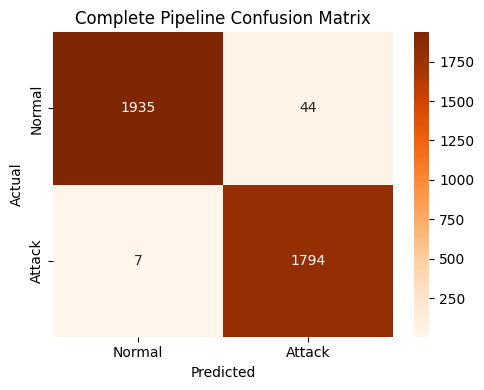

In [35]:
y_true = data.y[data.test_mask].cpu().numpy()
y_pred = pred_custom[data.test_mask].cpu().numpy() 

print("\n--- Pipeline Classification Report ---")
print(classification_report(y_true, y_pred, target_names=["Normal", "Attack"]))

# Visualization
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Complete Pipeline Confusion Matrix')
plt.tight_layout()
plt.savefig('GNN_complete.png')
plt.show()


Step 7: Training Support Vector Machine (Baseline)...
Fitting SVM on 17634 samples (This might take a minute...)
SVM Training Completed in 15.89 seconds.

--- SVM Classification Report ---
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.97      1979
      Attack       0.99      0.95      0.97      1801

    accuracy                           0.97      3780
   macro avg       0.97      0.97      0.97      3780
weighted avg       0.97      0.97      0.97      3780



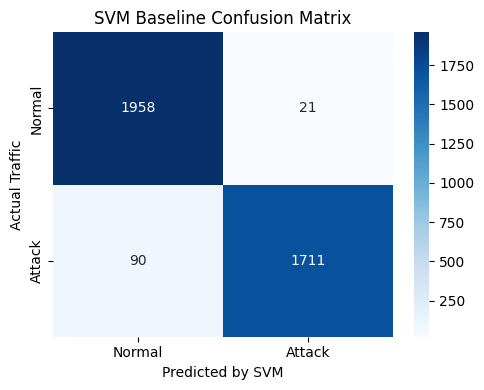

In [27]:
# ==========================================
# 7. SVM BASELINE COMPARISON
# ==========================================
from sklearn.svm import SVC
import time

print("\nStep 7: Training Support Vector Machine (Baseline)...")
start_time_svm = time.time()

# 1. Extract the exact same data splits using the PyTorch masks
# This guarantees a 1:1 fair comparison against the GAT model
X_train_svm = X_pca[data.train_mask.numpy()]
y_train_svm = y[data.train_mask.numpy()]

X_test_svm = X_pca[data.test_mask.numpy()]
y_test_svm = y[data.test_mask.numpy()]

# 2. Initialize SVM
# We use class_weight='balanced' to mimic the [1.0, 5.0] penalty we gave the GNN
# The RBF kernel is perfect here because PCA already concentrated the variance
svm_model = SVC(
    kernel='rbf', 
    class_weight='balanced', 
    probability=True, # Needed if you want to plot ROC/AUC curves later
    random_state=42
)

# 3. Train the Model
print(f"Fitting SVM on {len(X_train_svm)} samples (This might take a minute...)")
svm_model.fit(X_train_svm, y_train_svm)
print(f"SVM Training Completed in {time.time() - start_time_svm:.2f} seconds.")

# 4. Predict and Evaluate
y_pred_svm = svm_model.predict(X_test_svm)

print("\n--- SVM Classification Report ---")
print(classification_report(y_test_svm, y_pred_svm, target_names=["Normal", "Attack"]))

# 5. Visualize SVM Confusion Matrix
cm_svm = confusion_matrix(y_test_svm, y_pred_svm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted by SVM')
plt.ylabel('Actual Traffic')
plt.title('SVM Baseline Confusion Matrix')
plt.tight_layout()
plt.show()